In [15]:
import io
import sys
from contextlib import redirect_stdout
import os
import geopandas as gpd
import pandas as pd
import numpy as np
from datetime import datetime
from dateutil.relativedelta import relativedelta
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import pingouin as pg
import requests
from shapely.geometry import Polygon
from shapely.geometry import Point
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import contextily as cx
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature

# Clusters

Se corre algoritmo K-means para encontrar las regiones del país y poder hacer las respectivas divisiones para estudio

In [16]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn import linear_model
from sklearn import model_selection as ms
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [17]:
# Reading all sat condulted data

r = pd.read_csv(r'colombia_prom_filtered.csv', usecols=(2,3,5),delimiter=',') # se carga el archivo .csv
r = r[r['longitude'] >= -80] # se elimina gorgona
r

,latitude,longitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
0,-4.165,-69.995,1940.140508
1,-4.155,-70.005,1940.140503
2,-4.135,-69.965,1879.711405
3,-4.135,-69.955,1879.711295
4,-4.135,-69.945,1879.711346
...,...,...,...
494249,12.415,-71.585,1941.189894
494250,12.415,-71.575,1940.603705
494251,12.425,-71.605,1944.441511
494252,12.425,-71.595,1944.023515


In [18]:
# En caso de que no sean los datos corregidos:

#r['date']=pd.to_datetime(r['date'])
#r = r.groupby(['longitude','latitude']).mean(['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']).reset_index()


In [19]:
X = r[['longitude', 'latitude', 'CH4_column_volume_mixing_ratio_dry_air_bias_corrected']].to_numpy()

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### El siguiente script se ejecuta al final para obtener el k optimo

In [ ]:
# Find optimal number of clusters using elbow method
inertias = []
silhouette_scores = []

K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))


In [ ]:
# Plot elbow curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, inertias, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

# Plot silhouette scores
plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, 'rx-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.tight_layout()
plt.savefig('clusters_indicators.png', dpi=1200)
plt.show()

### A partir de aqui se ejecuta asumiendo que el k optimo es tres, buscando analizar el comportamiento de tres regiones principales.

In [20]:
# Fit final model with optimal k (let's say k=3 after analysis)
optimal_k = 3  # Change this based on the elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=50, n_init=100)
kmeans.fit(X_scaled)

# Add labels to original dataframe
r['cluster'] = kmeans.labels_
labe = kmeans.labels_



In [21]:
# Get the path to the file one directory up
# Get current working directory and go up one level
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
file_path = os.path.join(parent_dir, 'common/Departamentos_Junio_2024_shp/Departamento.shp')


# Load the file into a GeoDataFrame
gdf = gpd.read_file(file_path)

GeoDataFrame already has CRS: PROJCS["MAGNA-SIRGAS_2018_Origen-Nacional",GEOGCS["MAGNA-SIRGAS_2018",DATUM["Marco_Geocentrico_Nacional_de_Referencia_2018",SPHEROID["GRS_1980",6378137,298.257222101]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",4],PARAMETER["central_meridian",-73],PARAMETER["scale_factor",0.9992],PARAMETER["false_easting",5000000],PARAMETER["false_northing",2000000],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


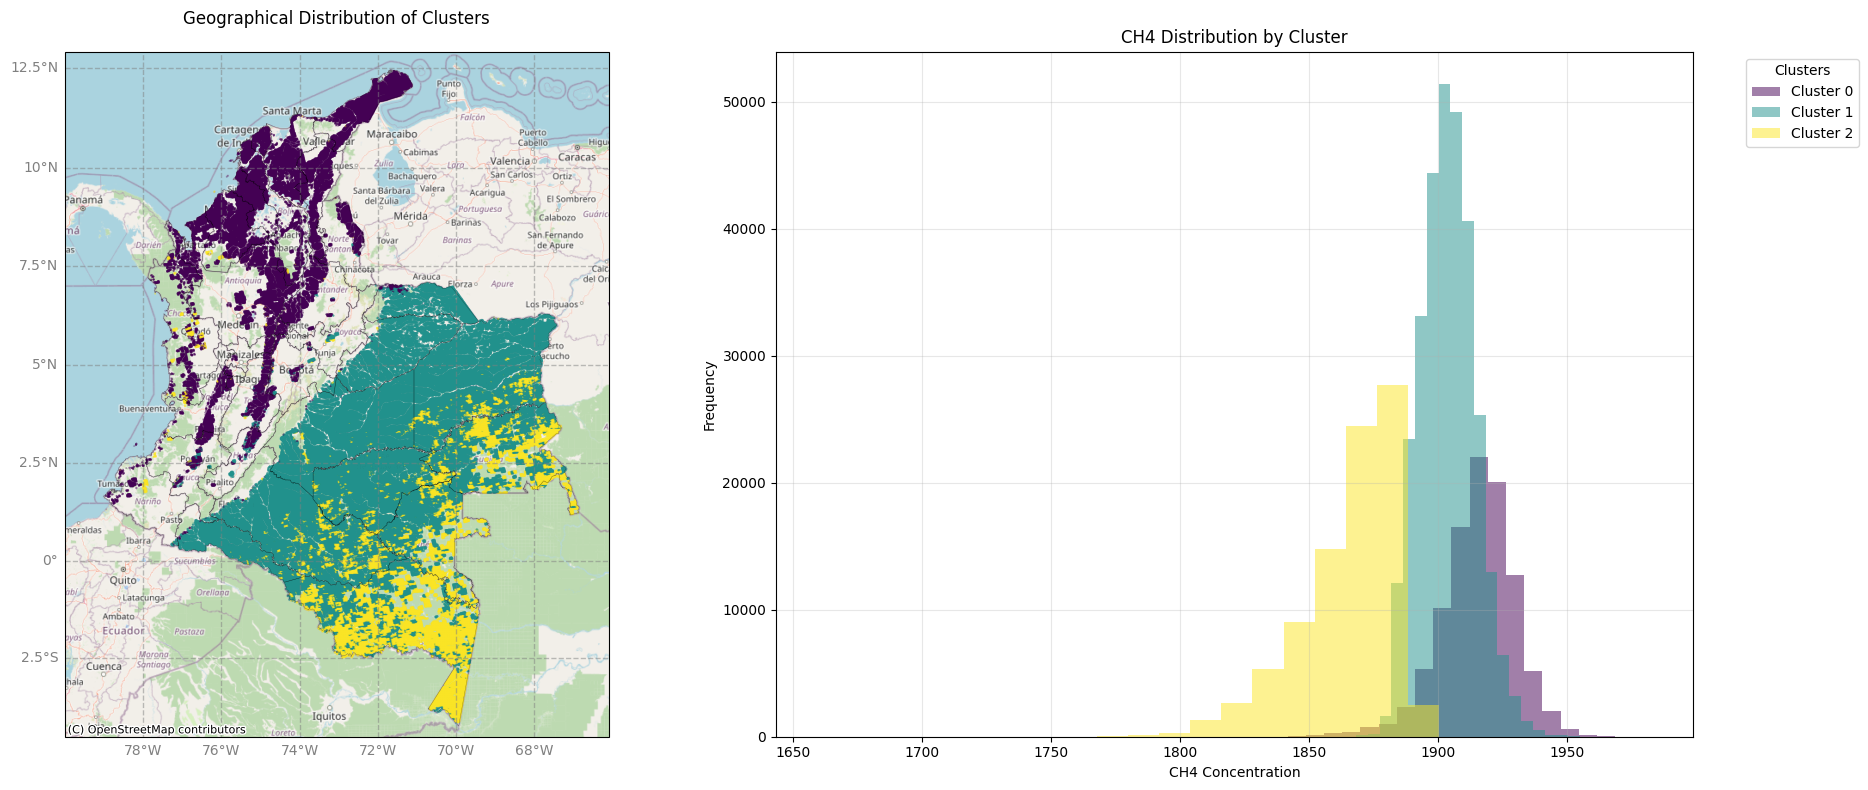


Cluster Statistics:
        CH4_column_volume_mixing_ratio_dry_air_bias_corrected                 \
                                                         mean    std   count   
cluster                                                                        
0                                                  1915.46     14.32   99682   
1                                                  1903.82     10.57  306169   
2                                                  1865.08     18.75   88395   

        longitude latitude  
             mean     mean  
cluster                     
0          -74.66     8.18  
1          -71.79     2.66  
2          -70.88     0.07  


In [22]:
# Create figure and axes
fig = plt.figure(figsize=(20, 8))
gs = GridSpec(1, 2, figure=fig)

# First subplot - Map with clusters
ax1 = fig.add_subplot(gs[0], projection=ccrs.epsg(3857))

# Set map extent
extent = [-80, -66.1, -4.5, 12.9]
ax1.set_extent(extent, crs=ccrs.PlateCarree())

# Create GeoDataFrame from your clusters data
gdf_points = gpd.GeoDataFrame(
    r,
    geometry=gpd.points_from_xy(r.longitude, r.latitude),
    crs="EPSG:4326"
)

# Convert to web mercator for contextily basemap
gdf_points_mercator = gdf_points.to_crs(epsg=3857)

# Define cluster colors
clusters = gdf_points['cluster'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(clusters)))

# Plot clusters on map
# for cluster, color in zip(clusters, colors):
#     cluster_data = gdf_points[gdf_points['cluster'] == cluster]
#     ax1.scatter(
#         cluster_data.longitude,
#         cluster_data.latitude,
#         color=color,
#         label=f'Cluster {cluster}',  # Add cluster number as label
#         transform=ccrs.PlateCarree(),
#         s=5,  # Marker size
#         alpha=0.6
#     )
    
# Plot clusters on map
scatter = ax1.scatter(
                        gdf_points.longitude,
                        gdf_points.latitude,
                        c=gdf_points.cluster,
                        cmap='viridis',
                        alpha=0.6,
                        transform=ccrs.PlateCarree(),
                        s=0.05  # Marker size, smaller values mean smaller circles
                    )

# Add basemap 
cx.add_basemap(ax1, 
               source=cx.providers.OpenStreetMap.Mapnik)

# Add gridlines
gl = ax1.gridlines(crs=ccrs.PlateCarree(), 
                   draw_labels=True,
                   linewidth=1, 
                   color='gray', 
                   alpha=0.5, 
                   linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

# Add colorbar to map
# cbar = plt.colorbar(scatter, ax=ax1)
# cbar.set_label('Cluster', fontsize=10)

# Add legend to map
# legend = ax1.legend(title='Clusters', loc='upper right', bbox_to_anchor=(1.15, 1))
# plt.setp(legend.get_title(), fontsize=10)  # Adjust legend title font size

if gdf.crs is None:
    # Only set CRS if it doesn't have one
    gdf.set_crs(epsg=4326, inplace=True)
else:
    print("GeoDataFrame already has CRS:", gdf.crs)
gdf = gdf.to_crs(epsg=3857)
              
gdf.plot(ax=ax1, edgecolor='black', facecolor='none', linewidth=0.3, alpha=0.4)


# Add title to map
ax1.set_title('Geographical Distribution of Clusters', pad=20)





# Second subplot - Methane distribution
ax2 = fig.add_subplot(gs[1])
colors = plt.cm.viridis(np.linspace(0, 1, optimal_k))  # Use same colormap as map

ax2.set_xlabel('CH4 Concentration')
ax2.set_ylabel('Frequency')
ax2.set_title('CH4 Distribution by Cluster')


for i in range(optimal_k):
    cluster_data = r[r['cluster'] == i]
    ax2.hist(cluster_data['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'], 
             alpha=0.5, 
             label=f'Cluster {i}',
             color=colors[i],  # Match colors with map
             bins=20)  # Adjust number of bins

# Add grid to histogram
ax2.grid(True, alpha=0.3)

# Customize histogram legend
ax2.legend(title='Clusters', 
          bbox_to_anchor=(1.05, 1), 
          loc='upper left')

# Adjust layout and save
plt.tight_layout()
plt.savefig('clusters_25.png', dpi=600, bbox_inches='tight')
plt.show()

# Print cluster statistics
print("\nCluster Statistics:")
print(r.groupby('cluster').agg({
    'CH4_column_volume_mixing_ratio_dry_air_bias_corrected': ['mean', 'std', 'count'],
    'longitude': 'mean',
    'latitude': 'mean'
}).round(2))

# Clasificación

Debido a que anteriormente, ningún clasificador hizo un buen trabajo, y simplemente tomaba toda la región del país como perteneciente a una misma intancia, se busca crear una red neuronal que haga la tarea de clasificación.

In [23]:
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.nn.functional as F

In [24]:
#X = r[['longitude', 'latitude', 'CH4_column_volume_mixing_ratio_dry_air_bias_corrected']].to_numpy()
y= r['cluster'].to_numpy()
X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)

In [25]:
X_train.shape

(331144, 2)

In [26]:
class Data(Dataset):
  def __init__(self, X_train, y_train):
    # need to convert float64 to float32 else
    # will get the following error
    # RuntimeError: expected scalar type Double but found Float
    self.X = torch.from_numpy(X_train.astype(np.float32))
    # need to convert float64 to Long else
    # will get the following error
    # RuntimeError: expected scalar type Long but found Float
    self.y = torch.from_numpy(y_train).type(torch.LongTensor)
    self.len = self.X.shape[0]

  def __getitem__(self, index):
    return self.X[index], self.y[index]
  def __len__(self):
    return self.len

In [27]:
traindata = Data(X_train, Y_train)
print(traindata[25])

(tensor([-70.3250,   4.6750]), tensor(1))


In [28]:

# number of features (len of X cols)
input_dim = 2
# number of hidden layers
hidden_layers = 25
#hidden_layers2 = 125
# number of classes (unique of y)
output_dim = len(np.unique(Y_train))
class Network(nn.Module):
    def __init__(self,hidden_layers):
        super(Network, self).__init__()
        self.linear1 = nn.Linear(input_dim, hidden_layers)
        #self.linearh1=nn.Linear(hidden_layers,hidden_layers2)
        self.linear2 = nn.Linear(hidden_layers, output_dim)
    def forward(self, x):
        x = F.leaky_relu(self.linear1(x))
        #x = torch.sigmoid(self.linearh1(x))
        x = self.linear2(x)
        #x = F.softmax(x)
        return x


In [29]:
epochs = 40
def run_epoch(epoch,ta,clf):
    criterion = nn.MultiMarginLoss()#nn.MultiMarginLoss()#nn.HingeEmbeddingLoss#nn.MultiLabelMarginLoss()##
    optimizer = torch.optim.Adam(clf.parameters(), lr=ta)
    for epoch in range(epochs):
      running_loss = 0.0
      for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        # set optimizer to zero grad to remove previous epoch gradients
        optimizer.zero_grad()
        # forward propagation
        outputs = clf(inputs)
        loss = criterion(outputs, labels)
        # backward propagation
        loss.backward()
        # optimize
        optimizer.step()
        running_loss += loss.item()
      # display statistics
    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.5f}')

In [30]:
def test_val(clf):
    correct, total = 0, 0
    # no need to calculate gradients during inference
    with torch.no_grad():
      for data in testloader:
        inputs, labels = data
        # calculate output by running through the network
        outputs = clf(inputs)
        # get the predictions
        __, predicted = torch.max(outputs.data, 1)
        # update results
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Accuracy of the network on the {len(testdata)} test data: {100 * correct // total} %')
    return correct/total

In [31]:
def parameters_train(ep,ta,hl):
    #nn_arch(hidden_layers)
    clf = Network(hl)
    epochs = ep
    lr=ta
    run_epoch(epoch,lr,clf)
    score=test_val(clf)
    return score

### --------------------------------

In [ ]:
#Se busca el mejor parámetro para la cantidad de capas ocultas
hd=np.arange(2,30,1)
epoch=40
lr=0.005
val_scores_hl=[]
batch_size = 20000
cv=5
for hidden_layers in hd:
    print(hidden_layers)
    val_scores_hl_cv=[]
    for j in range(cv):
        X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)
        traindata = Data(X_train, Y_train)
        trainloader = DataLoader(traindata, batch_size=batch_size,
                         shuffle=True, num_workers=10)
        testdata = Data(X_test, Y_test)
        testloader = DataLoader(testdata, batch_size=batch_size,
                                shuffle=True, num_workers=10)
        val_scores_hl_cv.append(parameters_train(epoch,lr,hidden_layers))
    val_scores_hl.append(np.mean(val_scores_hl_cv))

In [ ]:
#Se encuentra la mejor cantidad de puntos en la capa oculta
ind = np.argmax(val_scores_hl)
hl_star = hd[ind] #Resultó ser 17 25
print('HL_star =', hl_star)

plt.plot(hd,val_scores_hl)
plt.plot(np.ones(11)*hl_star,np.arange(0,1.1,0.1),'--r')
#plt.xlim(0.9,1)
#plt.ylim(0.9,1)
plt.xlabel('HL')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.grid(True)
plt.show()

In [ ]:
# Se busca el mejor valor para la tasa de aprendizaje
epoch=40
lr=np.arange(1e-5,0.01,5e-4)
val_scores_lr=[]
batch_size = 500
cv=4
for i in lr:
    #print(clf.parameters)
    print(i)
    val_scores_lr_cv=[]
    for j in range(cv):
        X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)
        traindata = Data(X_train, Y_train)
        trainloader = DataLoader(traindata, batch_size=batch_size,
                         shuffle=True, num_workers=10)
        testdata = Data(X_test, Y_test)
        testloader = DataLoader(testdata, batch_size=batch_size,
                                shuffle=True, num_workers=10)
        val_scores_lr_cv.append(parameters_train(epoch,i,hl_star))
    val_scores_lr.append(np.mean(val_scores_lr_cv))

In [ ]:
ind = np.argmax(val_scores_lr)
lr_star = lr[ind] # resulto ser LR_star =0.00601
print('LR_star =', lr_star)

plt.plot(lr,val_scores_lr)
plt.plot(np.ones(11)*lr_star,np.arange(0,1.1,0.1),'--r')
#plt.xlim(0.95,1)
#plt.ylim(0.95,1)
plt.xlabel('Learning Rate')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.grid(True)
plt.show()

In [ ]:
parameters_train(40,0.005,15)

In [ ]:
# save the trained model
clf = Network(hl_star)
criterion = nn.MultiMarginLoss()#nn.MultiMarginLoss()#nn.HingeEmbeddingLoss#nn.MultiLabelMarginLoss()##
optimizer = torch.optim.Adam(clf.parameters(), lr=lr_star)
epochs = 40
for epoch in range(epochs):
  running_loss = 0.0
  for i, data in enumerate(trainloader, 0):
    inputs, labels = data
    # set optimizer to zero grad to remove previous epoch gradients
    optimizer.zero_grad()
    # forward propagation
    outputs = clf(inputs)
    loss = criterion(outputs, labels)
    # backward propagation
    loss.backward()
    # optimize
    optimizer.step()
    running_loss += loss.item()
  # display statistics
  print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.5f}')
PATH = 'mymodel_prueba_corrected_filtered.pth'
torch.save(clf.state_dict(), PATH)

### ----------------------

In [32]:
# load the trained model
PATH = 'mymodel_prueba_corrected_filtered.pth'
clf = Network(22)
clf.load_state_dict(torch.load(PATH))

/tmp/ipykernel_15489/1516079928.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  clf.load_state_dict(torch.load(PATH))


<All keys matched successfully>

In [33]:
# mapa con la clasificación de resultado
#sns.scatterplot(x=inputs[:,0],y=inputs[:,1])#],hue='label',s=1,palette=sns.color_palette("tab10"))
y_pred=[]

batch_size=len(y)

testdata = Data(X[:,[0,1]], y)

testloader = DataLoader(testdata, batch_size=batch_size, shuffle=True, num_workers=10)
for data in testloader:
    inputs, labels = data
    # calculate output by running through the network
    outputs = clf(inputs)
    # get the predictions
    __, predicted = torch.max(outputs.data, 1)
    y_pred.append(predicted)


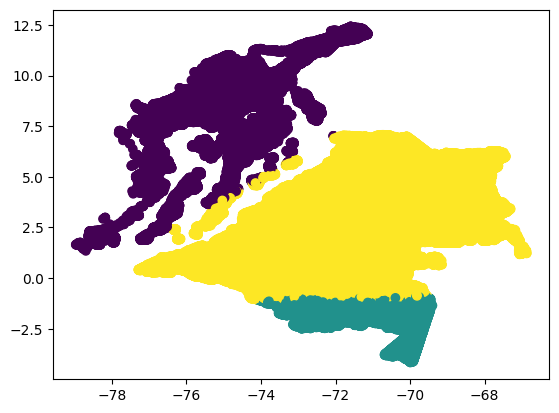

In [34]:
plt.scatter(inputs[:,0],inputs[:,1],c=predicted)

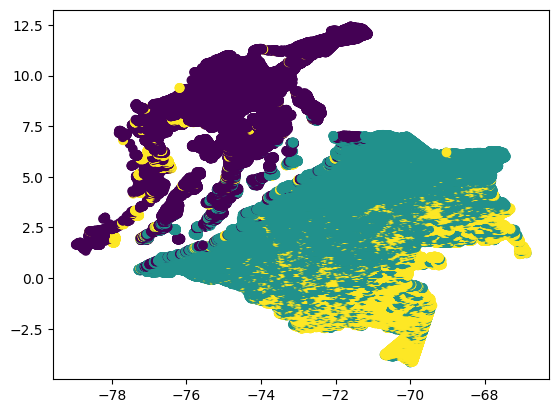

In [35]:
plt.scatter(X[:,0],X[:,1],c=y)

In [36]:
import ee
from shapely.geometry import shape, Point
ee.Initialize()

In [37]:
pacifico_asset = ee.FeatureCollection('projects/ee-hides/assets/pacifico')
magdalena_asset = ee.FeatureCollection('projects/ee-hides/assets/magdalena')


In [38]:
# Convert MultiPolygon from FeatureCollection to Shapely polygons
features_1 = pacifico_asset.getInfo()['features']
shapely_polygons = [shape(feat['geometry']) for feat in features_1]

# Update 'cluster' column with a fixed value if the point is inside any polygon
def update_cluster(row):
    point = Point(row['longitude'], row['latitude'])
    for polygon in shapely_polygons:
        if polygon.contains(point):
            return 3  # Set the fixed cluster value to 3
    return row['cluster']  # Keep the original cluster if not inside any polygon



In [39]:

predicted_cluster_array = predicted.numpy()
lon_array = inputs[:, 0].numpy()  # Extract longitude values
lat_array = inputs[:, 1].numpy()  # Extract latitude values

# Round the longitude array to 3 decimal places
lon_array_rounded = np.round(lon_array, 3)
lat_array_rounded = np.round(lat_array, 3)

# Create the DataFrame with the rounded longitude values
r_refined = pd.DataFrame({
    'latitude': lat_array_rounded,
    'longitude': lon_array_rounded,
    'cluster': predicted_cluster_array
})


r[['latitude', 'longitude']] = r[['latitude', 'longitude']].round(3)
r

,latitude,longitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,cluster
0,-4.165,-69.995,1940.140508,1
1,-4.155,-70.005,1940.140503,1
2,-4.135,-69.965,1879.711405,2
3,-4.135,-69.955,1879.711295,2
4,-4.135,-69.945,1879.711346,2
...,...,...,...,...
494249,12.415,-71.585,1941.189894,0
494250,12.415,-71.575,1940.603705,0
494251,12.425,-71.605,1944.441511,0
494252,12.425,-71.595,1944.023515,0


## matching the measure values in their correct place

In [40]:
## Computationally efficient mclassmethod # pribarlo y mejorarlo

# Round coordinates in both DataFrames to 3 decimals upfront
r_refined['lat_round'] = r_refined['latitude'].round(3)
r_refined['lon_round'] = r_refined['longitude'].round(3)
r['lat_round'] = r['latitude'].round(3)
r['lon_round'] = r['longitude'].round(3)

# Create a mapping of rounded coordinates to CH4 values (using first occurrence in `r`)
# Drop duplicates to avoid multiple matches
r_mapping = r.drop_duplicates(subset=['lat_round', 'lon_round'])[['lat_round', 'lon_round', 'CH4_column_volume_mixing_ratio_dry_air_bias_corrected']]

# Merge the mapping onto r_refined using left join (to retain all r_refined rows)
r_refined = r_refined.merge(
    r_mapping,
    on=['lat_round', 'lon_round'],
    how='left'
).drop(columns=['lat_round', 'lon_round'])  # Remove temporary columns

r_refined

,latitude,longitude,cluster,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
0,1.695,-72.074997,2,NaN
1,8.375,-76.455002,0,NaN
2,4.425,-71.364998,2,NaN
3,-1.185,-73.625000,1,NaN
4,0.985,-70.654999,2,NaN
...,...,...,...,...
494241,-1.325,-73.105003,1,NaN
494242,2.515,-70.404999,2,NaN
494243,3.185,-71.254997,2,NaN
494244,-1.515,-72.205002,1,NaN


In [41]:
### Metodo usando loops computacionalmente ineficiente

sorted_array = []
for i in range(len(r_refined['longitude'])):
    lat, lon = r_refined.loc[i, ['latitude', 'longitude']]
    lat = round(lat,3)
    lon = round(lon,3)
    value_i = r[(r['longitude'] == lon) & (r['latitude'] == lat)]['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
    
    if not value_i.empty:
        sorted_array.append(value_i)
    else:
        sorted_array.append(float("nan"))
        
r_refined['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'] = sorted_array
r_refined

,latitude,longitude,cluster,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
0,1.695,-72.074997,2,172026 1916.738382 Name: CH4_column_volume_...
1,8.375,-76.455002,0,442386 1914.027222 Name: CH4_column_volume_...
2,4.425,-71.364998,2,328966 1904.330485 Name: CH4_column_volume_...
3,-1.185,-73.625000,1,43317 1875.454125 Name: CH4_column_volume_m...
4,0.985,-70.654999,2,134469 1904.703236 Name: CH4_column_volume_...
...,...,...,...,...
494241,-1.325,-73.105003,1,39523 1894.335808 Name: CH4_column_volume_m...
494242,2.515,-70.404999,2,221374 1874.915187 Name: CH4_column_volume_...
494243,3.185,-71.254997,2,258208 1894.98994 Name: CH4_column_volume_m...
494244,-1.515,-72.205002,1,34340 1868.737769 Name: CH4_column_volume_m...


In [42]:

####### Codigo necesario en caso de hacer el metodo mas eficiente con merge o alguna otra función

# Merge 'r_refined' with 'r', selecting only the 'CH4_column_volume_mixing_ratio_dry_air_bias_corrected' column from 'r'
# r_refined = pd.merge(
#     r_refined, 
#     r[['latitude', 'longitude', 'CH4_column_volume_mixing_ratio_dry_air_bias_corrected']],  # Select columns from r
#     on=['latitude', 'longitude'],  # Columns to merge on
#     how='inner'  # Merge type (e.g., inner, left, right, outer)
# )


In [43]:
# updating the clusters and adding separately the pacifico and magdalena bassin, resulting in 5 clusters instead of 3

r_refined['cluster'] = r_refined.apply(update_cluster, axis=1)

In [44]:
# Convert MultiPolygon from FeatureCollection to Shapely polygons
features_2 = magdalena_asset.getInfo()['features']
shapely_polygons = [shape(feat['geometry']) for feat in features_2]

# Update 'cluster' column with a fixed value if the point is inside any polygon
def update_cluster(row):
    point = Point(row['longitude'], row['latitude'])
    for polygon in shapely_polygons:
        if polygon.contains(point):
            return 4  # Set the fixed cluster value to 3
    return row['cluster']  # Keep the original cluster if not inside any polygon



In [45]:
r_refined['cluster'] = r_refined.apply(update_cluster, axis=1)

r_refined = r_refined.sort_values(by='cluster')
# sort the dataframe by clusters_100.png



In [46]:
# Extract the first value from each Series in the column
r_refined['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'] = r_refined['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].apply(lambda x: x.iloc[0])


5
GeoDataFrame already has CRS: EPSG:3857


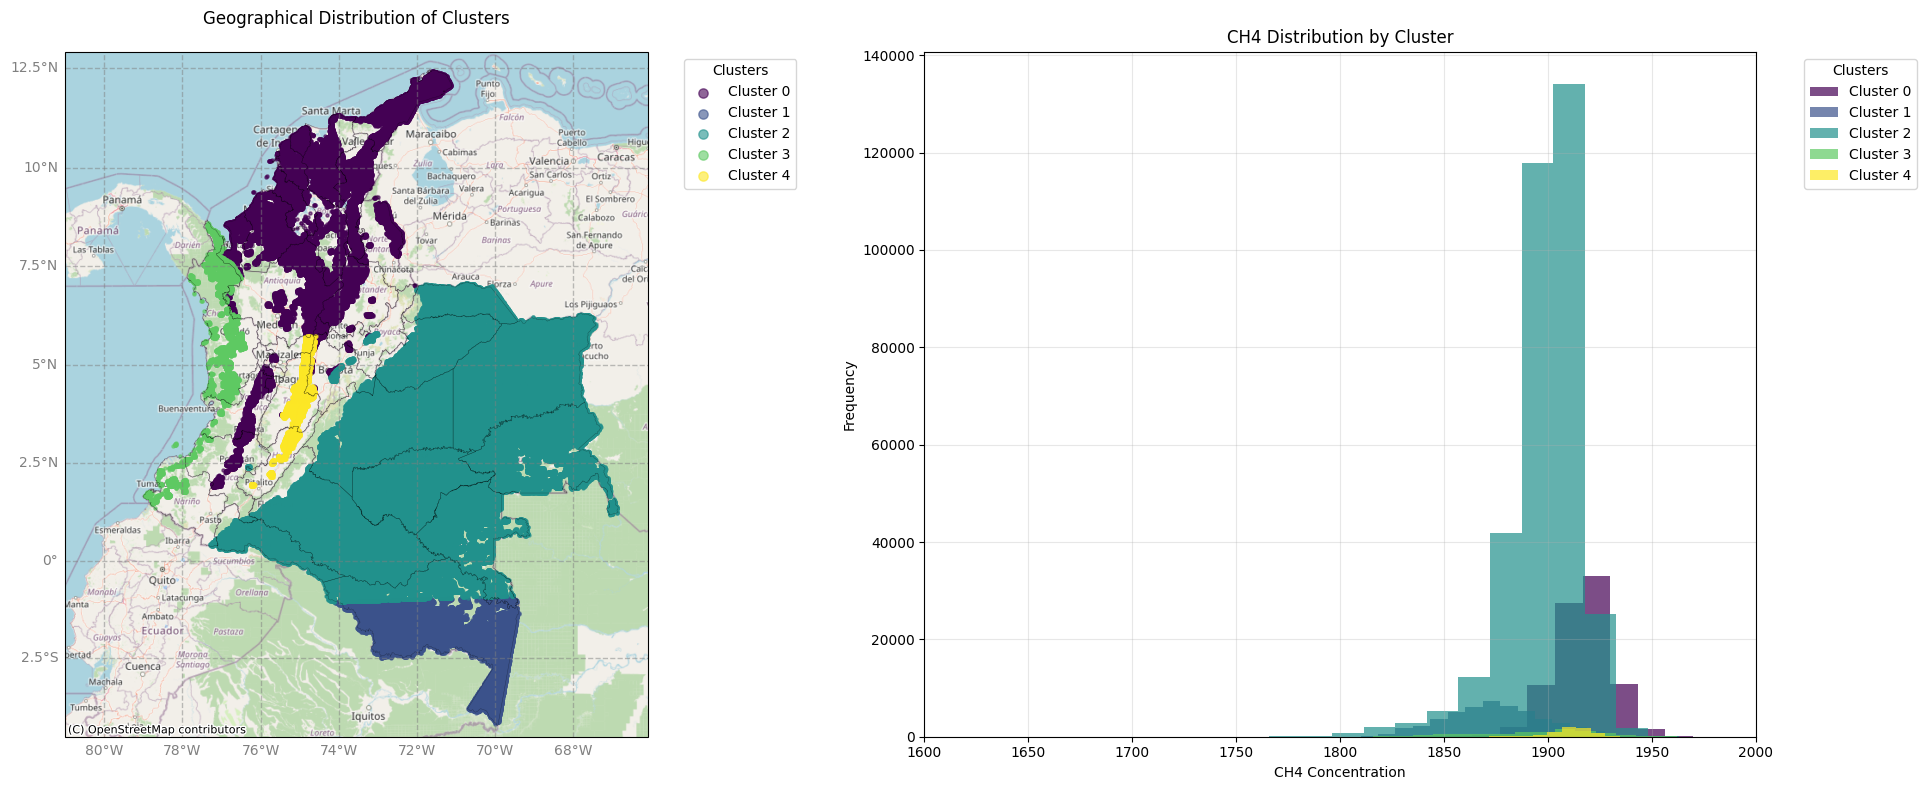


Cluster Statistics:
        CH4_column_volume_mixing_ratio_dry_air_bias_corrected                 \
                                                         mean    std   count   
cluster                                                                        
0                                                  1916.21     14.37   86283   
1                                                  1874.20     23.89   48675   
2                                                  1898.41     17.99  344046   
3                                                  1895.03     28.40    8847   
4                                                  1911.13     11.45    6395   

         longitude latitude  
              mean     mean  
cluster                      
0       -74.440002     8.67  
1       -71.309998    -1.95  
2       -71.589996     2.64  
3       -77.120003     5.58  
4       -75.040001     4.08  


In [47]:
# Create figure and axes
fig = plt.figure(figsize=(20, 8))
gs = GridSpec(1, 2, figure=fig)

# First subplot - Map with clusters
ax1 = fig.add_subplot(gs[0], projection=ccrs.epsg(3857))

# Set map extent
extent = [-81, -66.1, -4.5, 12.9]
ax1.set_extent(extent, crs=ccrs.PlateCarree())

# Create GeoDataFrame from your clusters data
gdf_points = gpd.GeoDataFrame(
    r_refined,
    geometry=gpd.points_from_xy(r_refined.longitude, r_refined.latitude),
    crs="EPSG:4326"
)

# Convert to web mercator for contextily basemap
gdf_points_mercator = gdf_points.to_crs(epsg=3857)

# Convertir la columna 'cluster' a enteros
gdf_points['cluster'] = gdf_points['cluster'].astype(int)

# Verificar los valores únicos después de la conversión
clusters = gdf_points['cluster'].unique()

print(len(clusters))
colors = plt.cm.viridis(np.linspace(0, 1, len(clusters)))

# Plot clusters on map with legend
for cluster, color in zip(clusters, colors):
    cluster_data = gdf_points[gdf_points['cluster'] == cluster]
    ax1.scatter(
        cluster_data.longitude,
        cluster_data.latitude,
        color=color,
        label=f'Cluster {cluster}',  # Add cluster number as label
        transform=ccrs.PlateCarree(),
        s=5,  # Marker size
        alpha=0.6
    )

# Add basemap 
cx.add_basemap(ax1, 
               source=cx.providers.OpenStreetMap.Mapnik)

# Add gridlines
gl = ax1.gridlines(crs=ccrs.PlateCarree(), 
                   draw_labels=True,
                   linewidth=1, 
                   color='gray', 
                   alpha=0.5, 
                   linestyle='--')

gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

# Add colorbar to map
# cbar = plt.colorbar(scatter, ax=ax1)
# cbar.set_label('Cluster', fontsize=10)

# Add legend to map with larger points
legend = ax1.legend(
    title='Clusters', 
    loc='upper left', 
    bbox_to_anchor=(1.05, 1),
    markerscale=3  # Increase the size of points in the legend
)

# Adjust legend title font size
plt.setp(legend.get_title(), fontsize=10)



if gdf.crs is None:
    # Only set CRS if it doesn't have one
    gdf.set_crs(epsg=4326, inplace=True)
else:
    print("GeoDataFrame already has CRS:", gdf.crs)
gdf = gdf.to_crs(epsg=3857)
              
gdf.plot(ax=ax1, edgecolor='black', facecolor='none', linewidth=0.3, alpha=0.4)


# Add title to map
ax1.set_title('Geographical Distribution of Clusters', pad=20)





# Second subplot - Methane distribution
ax2 = fig.add_subplot(gs[1])
#colors = plt.cm.viridis(np.linspace(0, 1, optimal_k+2))  # Use same colormap as map

# color_f = np.zeros([5,4])
# color_f[0,:] = colors[1,:]
# color_f[1,:] = colors[2,:]
# color_f[2,:] = colors[0,:]
# color_f[3,:] = colors[4,:]
# color_f[4,:] = colors[3,:]


ax2.set_xlabel('CH4 Concentration')
ax2.set_ylabel('Frequency')
ax2.set_title('CH4 Distribution by Cluster')


for i in range(5):
    cluster_data = r_refined[r_refined['cluster'] == i]
    ax2.hist(cluster_data['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'], 
             alpha=0.7, 
             label=f'Cluster {i}',
             color=colors[i],  # Match colors with map
             bins=20)  # Adjust number of bins

# Add grid to histogram
ax2.grid(True, alpha=0.3)

# Customize histogram legend
ax2.legend(title='Clusters', 
          bbox_to_anchor=(1.05, 1), 
          loc='upper left')

ax2.set_xlim([1600, 2000])


# Adjust layout and save
plt.tight_layout()
plt.savefig('clusters.png', dpi=600, bbox_inches='tight')
plt.show()

# Print cluster statistics
print("\nCluster Statistics:")
print(r_refined.groupby('cluster').agg({
    'CH4_column_volume_mixing_ratio_dry_air_bias_corrected': ['mean', 'std', 'count'],
    'longitude': 'mean',
    'latitude': 'mean'
}).round(2))

In [48]:
r_refined.to_csv('mean_values_clustered_v1.csv', index = False, encoding='utf-8')